In [573]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/AI_Impact_Student_Life_2026.csv")

# -----------------------------
# 1. Feature Engineering
# -----------------------------
df['GPA_Change'] = df['GPA_Post_AI'] - df['GPA_Baseline']
df['Improved'] = df['GPA_Change'] > 0

usage_median = df['Task_Frequency_Daily'].median()
df['High_Usage'] = df['Task_Frequency_Daily'] > usage_median

# -----------------------------
# 2. AI Usage Patterns
# -----------------------------
print("\n--- AI USAGE PATTERNS ---")

print("\nMost Used Tools:\n", df['Primary_AI_Tool'].value_counts())
print("\nMain Usage Case:\n", df['Main_Usage_Case'].value_counts())

print("\nUsage by Age:\n", df.groupby('Age')['Task_Frequency_Daily'].mean())
print("\nUsage by Major:\n", df.groupby('Major')['Task_Frequency_Daily'].mean())

# -----------------------------
# 3. Ethical Concern Distribution (CORRECT WAY)
# -----------------------------
print("\n--- ETHICAL CONCERN DISTRIBUTION ---")

print("\nCounts:\n", df['AI_Ethics_Concern'].value_counts())

print("\nPercentages:\n",
      df['AI_Ethics_Concern'].value_counts(normalize=True) * 100)

# -----------------------------
# 4. Tool vs Ethical Concern
# -----------------------------
print("\n--- TOOL VS ETHICAL CONCERN ---")

tool_ethics = pd.crosstab(df['Primary_AI_Tool'],
                         df['AI_Ethics_Concern'],
                         normalize='index') * 100

print(tool_ethics)

print("\nTools with highest HIGH concern:\n",
      tool_ethics['High'].sort_values(ascending=False))

# -----------------------------
# 5. Age vs Ethical Concern
# -----------------------------
print("\n--- AGE VS ETHICAL CONCERN ---")

age_ethics = pd.crosstab(df['Age'],
                        df['AI_Ethics_Concern'],
                        normalize='index') * 100

print(age_ethics)

# -----------------------------
# 6. Academic Impact
# -----------------------------
print("\n--- ACADEMIC IMPACT ---")

print(df[['GPA_Baseline', 'GPA_Post_AI', 'GPA_Change']].describe())

print("\nImproved:", df['Improved'].sum())
print("Declined:", (~df['Improved']).sum())

print("\nUsage vs GPA Change:\n",
      df.groupby('Task_Frequency_Daily')['GPA_Change'].mean())

# -----------------------------
# 7. Productivity (Time Saved)
# -----------------------------
print("\n--- TIME SAVED ---")

print(df['Time_Saved_Hours_Weekly'].describe())

print("\nUsage vs Time Saved:\n",
      df.groupby('Task_Frequency_Daily')['Time_Saved_Hours_Weekly'].mean())

print("\nUsage Case vs Time Saved:\n",
      df.groupby('Main_Usage_Case')['Time_Saved_Hours_Weekly'].mean())

# -----------------------------
# 8. Career Confidence
# -----------------------------
print("\n--- CAREER CONFIDENCE ---")

print("\nGPA Change vs Confidence:\n",
      df.groupby(pd.cut(df['GPA_Change'], bins=3))['Career_Confidence_Score'].mean())

print("\nUsage vs Confidence:\n",
      df.groupby('Task_Frequency_Daily')['Career_Confidence_Score'].mean())

print("\nCorrelation:\n",
      df[['Career_Confidence_Score', 'GPA_Change', 'Task_Frequency_Daily']].corr())

# -----------------------------
# 9. Ethical Concern vs Outcomes (VERY IMPORTANT)
# -----------------------------
print("\n--- ETHICS VS OUTCOMES ---")

ethics_outcomes = df.groupby('AI_Ethics_Concern').agg({
    'GPA_Change': 'mean',
    'Time_Saved_Hours_Weekly': 'mean',
    'Career_Confidence_Score': 'mean',
    'Task_Frequency_Daily': 'mean'
})

print(ethics_outcomes)

# GPA improvement by ethics (percentage)
gpa_by_ethics = pd.crosstab(df['AI_Ethics_Concern'],
                           df['Improved'],
                           normalize='index') * 100

print("\nGPA Improvement by Ethics:\n", gpa_by_ethics)

# -----------------------------
# 10. Risk Behavior (CRITICAL)
# -----------------------------
print("\n--- RISK BEHAVIOR ---")

risk_behavior = df[
    (df['AI_Ethics_Concern'] == 'High') &
    (df['High_Usage'])
]

print("High concern + High usage:", len(risk_behavior))

# -----------------------------
# 11. Dependency vs Benefit
# -----------------------------
print("\n--- DEPENDENCY VS BENEFIT ---")

dependent = df[
    (df['High_Usage']) &
    (df['GPA_Change'] <= 0)
]

effective = df[
    (df['High_Usage']) &
    (df['GPA_Change'] > 0)
]

print("Dependent Users:", len(dependent))
print("Effective Users:", len(effective))

# -----------------------------
# 12. Student Segmentation
# -----------------------------
print("\n--- STUDENT SEGMENTATION ---")

benefit = df[
    (df['GPA_Change'] > 0) &
    (df['Time_Saved_Hours_Weekly'] > df['Time_Saved_Hours_Weekly'].mean()) &
    (df['Career_Confidence_Score'] > df['Career_Confidence_Score'].mean()) &
    (df['AI_Ethics_Concern'] == 'Low')
]

risk = df[
    (df['GPA_Change'] <= 0) &
    (df['High_Usage']) &
    (df['AI_Ethics_Concern'] == 'High') &
    (df['Career_Confidence_Score'] < df['Career_Confidence_Score'].mean())
]

print("Benefiting Students:", len(benefit))
print("At-Risk Students:", len(risk))

# -----------------------------
# 13. Age vs Confidence
# -----------------------------
print("\n--- AGE VS CONFIDENCE ---")

print(df.groupby('Age')['Career_Confidence_Score'].mean())

# -----------------------------
# FINAL CONCLUSION
# -----------------------------
print("\n--- FINAL INSIGHT ---")
print("""
1. AI is widely used, mainly for assignments and exam preparation.

2. It significantly improves productivity by saving time,
   but does not guarantee GPA improvement.

3. Some students improve academically and gain confidence,
   while others become dependent with no performance gain.

4. Ethical concern distribution shows:
   - Many students are aware of risks
   - But high concern students still use AI frequently
   → Indicates risky behavior (privacy trade-off)

5. Tools differ in ethical concern levels,
   meaning some platforms create more trust issues.

6. Age differences show variation in awareness and confidence.

7. Clear segmentation:
   - Benefiting students (efficient + improved + confident)
   - At-risk students (dependent + concerned + low confidence)

FINAL CONCLUSION:
AI is not inherently good or bad.
Its impact depends on usage behavior.

Institutions must guide students toward
responsible and effective AI usage.
""")


--- AI USAGE PATTERNS ---

Most Used Tools:
 Primary_AI_Tool
GitHub Copilot    311
Gemini Pro        302
Perplexity        302
Claude 3.5        297
ChatGPT-4o        288
Name: count, dtype: int64

Main Usage Case:
 Main_Usage_Case
Exam Prep            341
Literature Review    308
Essay Drafting       301
Brainstorming        286
Code Debugging       264
Name: count, dtype: int64

Usage by Age:
 Age
18    5.123656
19    5.392473
20    5.460000
21    5.207650
22    5.920635
23    5.413043
24    5.471264
25    5.267677
Name: Task_Frequency_Daily, dtype: float64

Usage by Major:
 Major
Biology                    5.200772
Business Administration    5.546875
Data Science               5.335907
Fine Arts                  5.186312
Modern History             5.547511
Software Engineering       5.669421
Name: Task_Frequency_Daily, dtype: float64

--- ETHICAL CONCERN DISTRIBUTION ---

Counts:
 AI_Ethics_Concern
Low       523
High      496
Medium    481
Name: count, dtype: int64

Percentages:
 A

/tmp/ipykernel_2000/1332686356.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['GPA_Change'], bins=3))['Career_Confidence_Score'].mean())


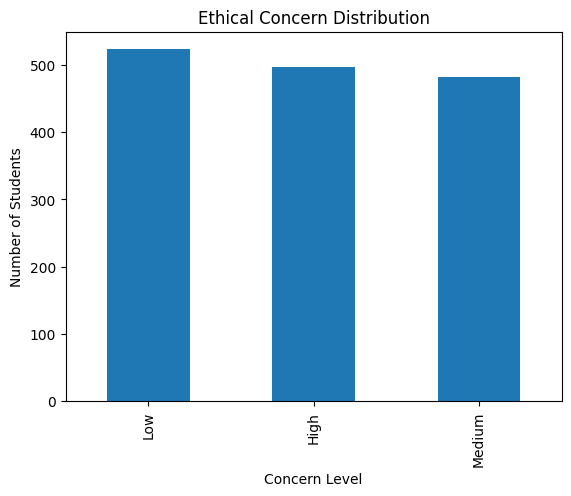

In [574]:
import matplotlib.pyplot as plt

plt.figure()
df['AI_Ethics_Concern'].value_counts().plot(kind='bar')
plt.title("Ethical Concern Distribution")
plt.xlabel("Concern Level")
plt.ylabel("Number of Students")
plt.savefig("chart1.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

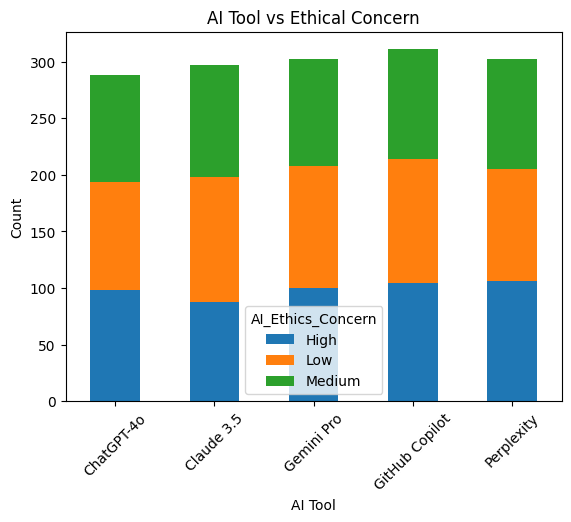

In [575]:
plt.figure()
pd.crosstab(df['Primary_AI_Tool'], df['AI_Ethics_Concern']).plot(kind='bar', stacked=True)
plt.title("AI Tool vs Ethical Concern")
plt.xlabel("AI Tool")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("chart2.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

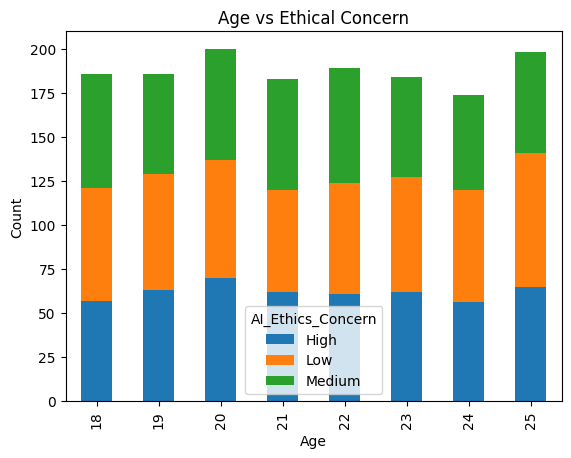

In [576]:
plt.figure()
pd.crosstab(df['Age'], df['AI_Ethics_Concern']).plot(kind='bar', stacked=True)
plt.title("Age vs Ethical Concern")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("chart3.png", dpi=300, bbox_inches='tight')
plt.show()

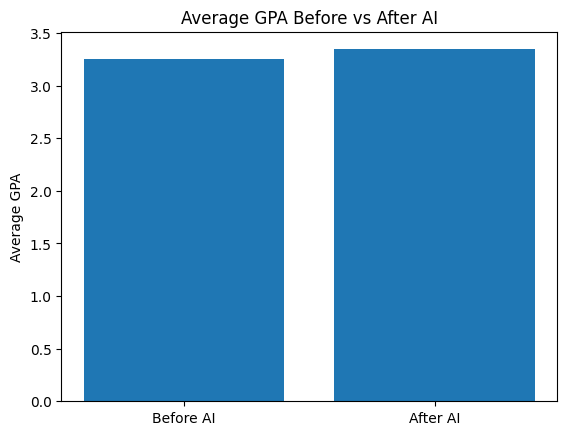

In [577]:
plt.figure()
avg_gpa = [df['GPA_Baseline'].mean(), df['GPA_Post_AI'].mean()]
labels = ['Before AI', 'After AI']

plt.bar(labels, avg_gpa)
plt.title("Average GPA Before vs After AI")
plt.ylabel("Average GPA")
plt.savefig("chart4.png", dpi=300, bbox_inches='tight')
plt.show()

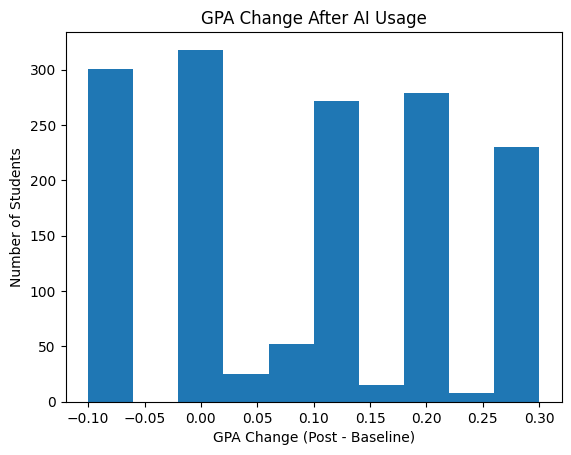

In [578]:
plt.figure()
plt.hist(df['GPA_Change'])
plt.title("GPA Change After AI Usage")
plt.xlabel("GPA Change (Post - Baseline)")
plt.ylabel("Number of Students")
plt.savefig("chart5.png", dpi=300, bbox_inches='tight')
plt.show()

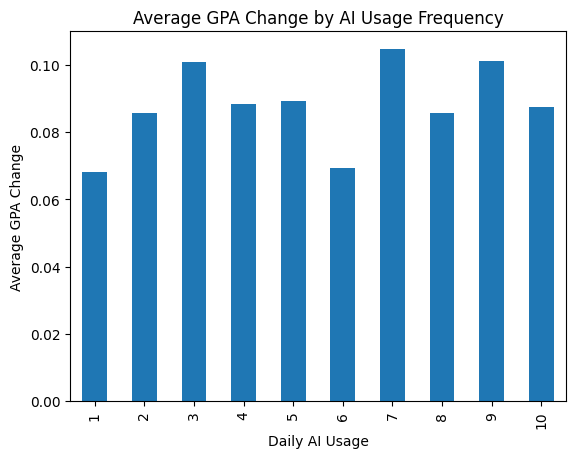

In [579]:
plt.figure()

df.groupby('Task_Frequency_Daily')['GPA_Change'].mean().plot(kind='bar')

plt.title("Average GPA Change by AI Usage Frequency")
plt.xlabel("Daily AI Usage")
plt.ylabel("Average GPA Change")
plt.savefig("chart6.png", dpi=300, bbox_inches='tight')
plt.show()

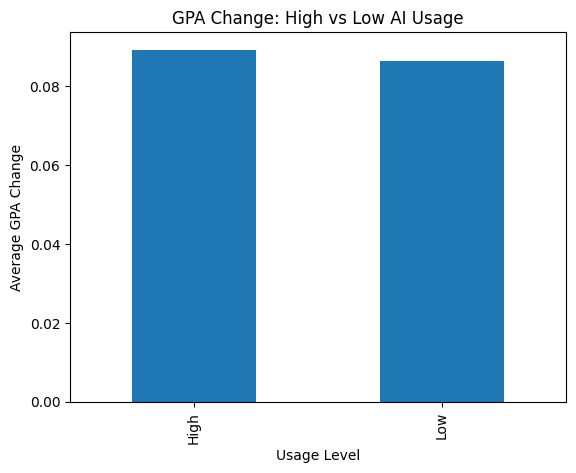

In [580]:
df['Usage_Level'] = df['Task_Frequency_Daily'].apply(
    lambda x: 'High' if x > df['Task_Frequency_Daily'].median() else 'Low'
)

plt.figure()

df.groupby('Usage_Level')['GPA_Change'].mean().plot(kind='bar')

plt.title("GPA Change: High vs Low AI Usage")
plt.xlabel("Usage Level")
plt.ylabel("Average GPA Change")
plt.savefig("chart7.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

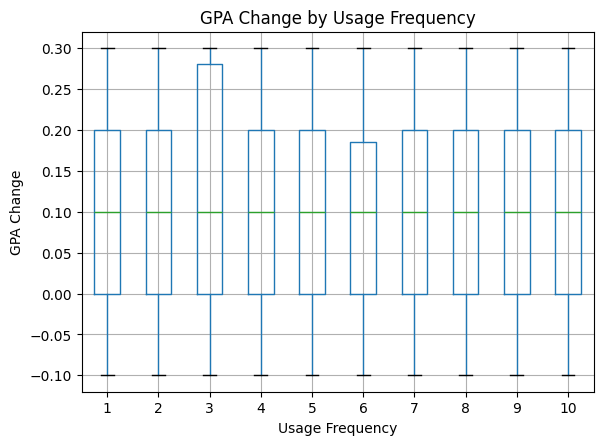

In [581]:
plt.figure()

df.boxplot(column='GPA_Change', by='Task_Frequency_Daily')

plt.title("GPA Change by Usage Frequency")
plt.suptitle("")
plt.xlabel("Usage Frequency")
plt.ylabel("GPA Change")
plt.savefig("chart7.png", dpi=300, bbox_inches='tight')
plt.show()

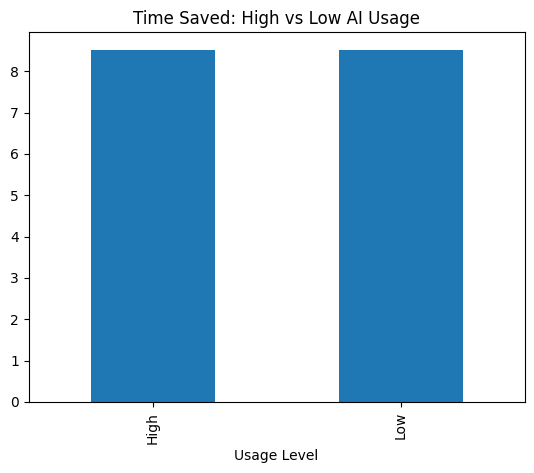

In [582]:
df['Usage_Level'] = df['Task_Frequency_Daily'].apply(
    lambda x: 'High' if x > df['Task_Frequency_Daily'].median() else 'Low'
)

plt.figure()

df.groupby('Usage_Level')['Time_Saved_Hours_Weekly'].mean().plot(kind='bar')

plt.title("Time Saved: High vs Low AI Usage")
plt.xlabel("Usage Level")
plt.savefig("chart8.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

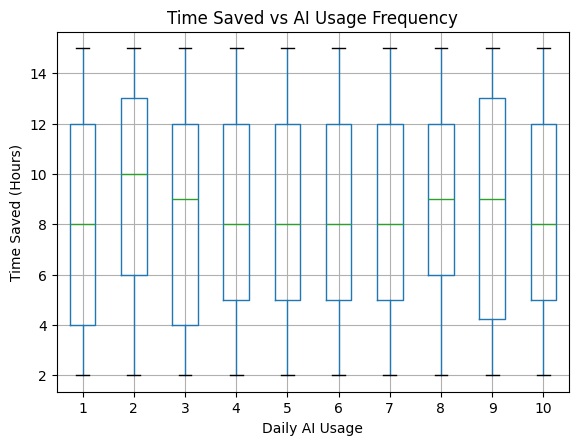

In [583]:
plt.figure()

df.boxplot(column='Time_Saved_Hours_Weekly', by='Task_Frequency_Daily')

plt.title("Time Saved vs AI Usage Frequency")
plt.suptitle("")
plt.xlabel("Daily AI Usage")
plt.ylabel("Time Saved (Hours)")
plt.savefig("chart9.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2000/1808830837.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['GPA_Change'], bins=5))['Career_Confidence_Score'].mean().plot(kind='bar')


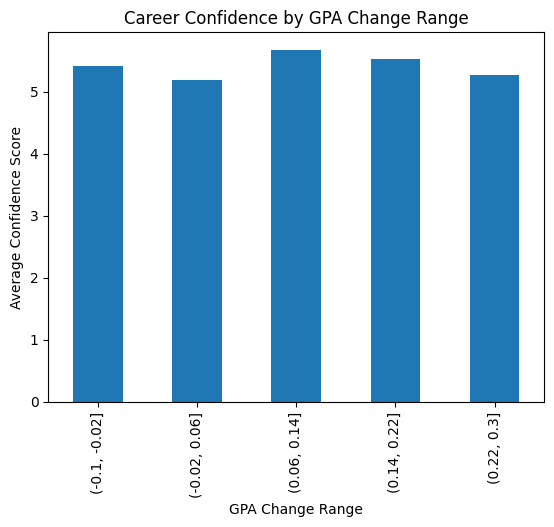

In [584]:
plt.figure()

df.groupby(pd.cut(df['GPA_Change'], bins=5))['Career_Confidence_Score'].mean().plot(kind='bar')

plt.title("Career Confidence by GPA Change Range")
plt.xlabel("GPA Change Range")
plt.ylabel("Average Confidence Score")
plt.savefig("chart10.png", dpi=300, bbox_inches='tight')
plt.show()

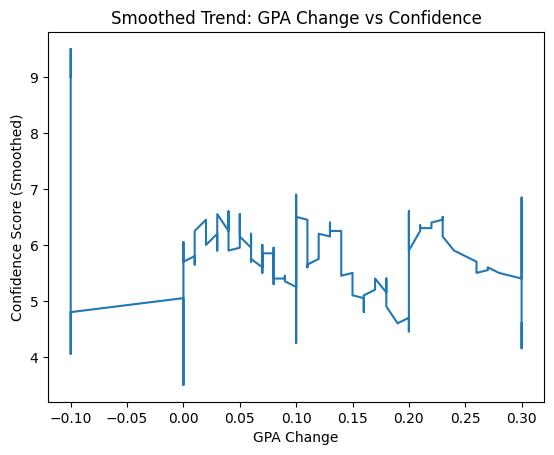

In [585]:
import matplotlib.pyplot as plt

temp = df[['GPA_Change', 'Career_Confidence_Score']].sort_values('GPA_Change')

temp['smoothed'] = temp['Career_Confidence_Score'].rolling(window=20, min_periods=1).mean()

plt.figure()

plt.plot(temp['GPA_Change'], temp['smoothed'])

plt.title("Smoothed Trend: GPA Change vs Confidence")
plt.xlabel("GPA Change")
plt.ylabel("Confidence Score (Smoothed)")
plt.savefig("chart11.png", dpi=300, bbox_inches='tight')
plt.show()

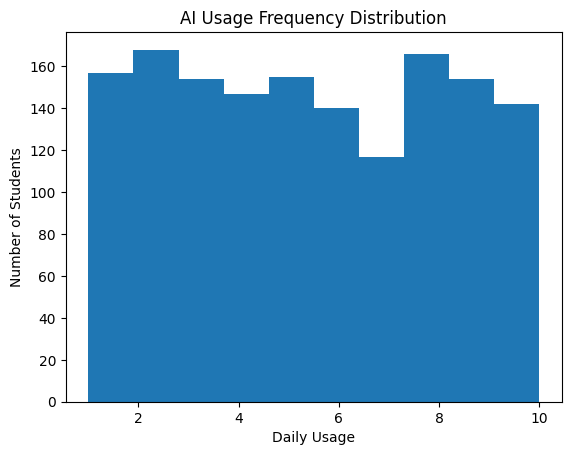

In [586]:
plt.figure()
plt.hist(df['Task_Frequency_Daily'])
plt.title("AI Usage Frequency Distribution")
plt.xlabel("Daily Usage")
plt.ylabel("Number of Students")
plt.savefig("chart12.png", dpi=300, bbox_inches='tight')
plt.show()

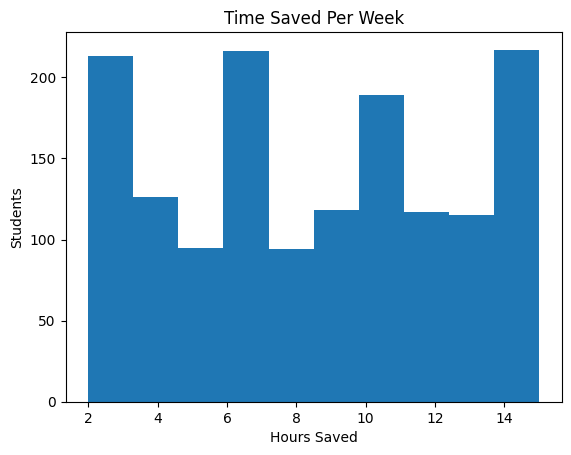

In [587]:
plt.figure()
plt.hist(df['Time_Saved_Hours_Weekly'])
plt.title("Time Saved Per Week")
plt.xlabel("Hours Saved")
plt.ylabel("Students")
plt.savefig("chart13.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

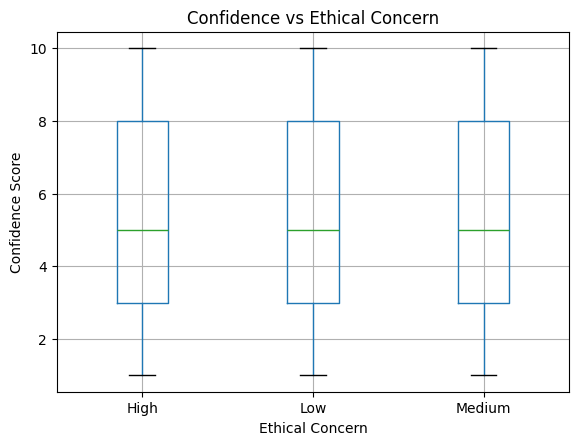

In [588]:
plt.figure()
df.boxplot(column='Career_Confidence_Score', by='AI_Ethics_Concern')
plt.title("Confidence vs Ethical Concern")
plt.suptitle("")
plt.xlabel("Ethical Concern")
plt.ylabel("Confidence Score")
plt.savefig("chart14.png", dpi=300, bbox_inches='tight')
plt.show()

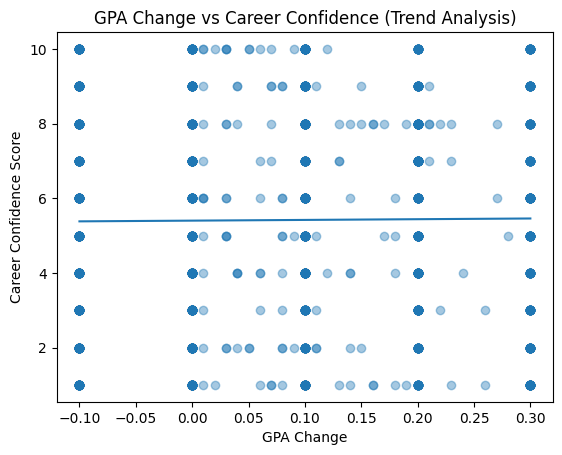

In [589]:
import matplotlib.pyplot as plt
import numpy as np

# Sort data for clean trend line
temp = df[['GPA_Change', 'Career_Confidence_Score']].sort_values('GPA_Change')

x = temp['GPA_Change']
y = temp['Career_Confidence_Score']

plt.figure()

# Scatter (lighter for readability)
plt.scatter(x, y, alpha=0.4)

# Trend line (correct + smooth)
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x))

plt.title("GPA Change vs Career Confidence (Trend Analysis)")
plt.xlabel("GPA Change")
plt.ylabel("Career Confidence Score")
plt.show()

In [590]:
df[['GPA_Change', 'Career_Confidence_Score']].corr()

,GPA_Change,Career_Confidence_Score
GPA_Change,1.000000,0.009095
Career_Confidence_Score,0.009095,1.000000


In [591]:
df['Performance_Group'] = df['GPA_Change'].apply(
    lambda x: 'Improved' if x > 0 else 'Not Improved'
)

df.groupby('Performance_Group')['Career_Confidence_Score'].mean()

,Career_Confidence_Score
Performance_Group,
Improved,5.531320
Not Improved,5.249175


Confidence_Level  Low  Medium  High
Age                                
18                 83      57    46
19                 67      57    62
20                 75      69    56
21                 82      53    48
22                 88      54    47
23                 86      45    53
24                 70      55    49
25                 72      54    72


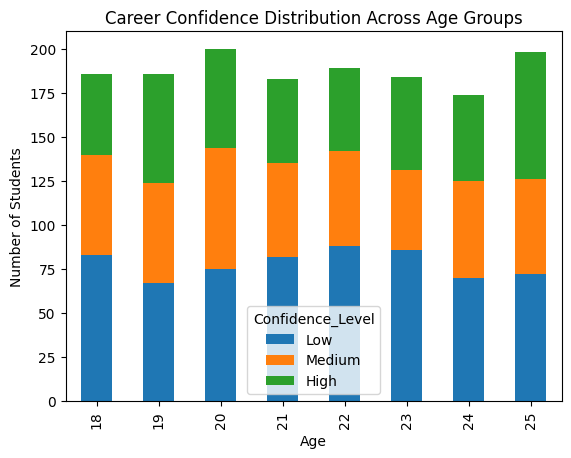

In [592]:
df['Confidence_Level'] = pd.qcut(
    df['Career_Confidence_Score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)
import pandas as pd

confidence_by_age = pd.crosstab(
    df['Age'],
    df['Confidence_Level']
)

print(confidence_by_age)
import matplotlib.pyplot as plt

confidence_by_age.plot(kind='bar', stacked=True)

plt.title("Career Confidence Distribution Across Age Groups")
plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.savefig("chart16.png", dpi=300, bbox_inches='tight')
plt.show()

In [593]:
# GPA change
df['GPA_Change'] = df['GPA_Post_AI'] - df['GPA_Baseline']

# Thresholds
time_mean = df['Time_Saved_Hours_Weekly'].mean()
conf_mean = df['Career_Confidence_Score'].mean()

# Segment definition
df['Student_Type'] = df.apply(
    lambda row: 'Benefiting'
    if (row['GPA_Change'] > 0) and
       (row['Time_Saved_Hours_Weekly'] > time_mean) and
       (row['Career_Confidence_Score'] > conf_mean) and
       (row['AI_Ethics_Concern'] == 'Low')
    else 'Non-Benefiting',
    axis=1
)
print(df['Student_Type'].value_counts())
df.groupby('Student_Type')[[
    'GPA_Change',
    'Time_Saved_Hours_Weekly',
    'Career_Confidence_Score'
]].mean()

Student_Type
Non-Benefiting    1435
Benefiting          65
Name: count, dtype: int64


,GPA_Change,Time_Saved_Hours_Weekly,Career_Confidence_Score
Student_Type,,,
Benefiting,0.182462,12.138462,7.876923
Non-Benefiting,0.083443,8.345645,5.305923


Student_Type
Non-Benefiting    95.666667
Benefiting         4.333333
Name: count, dtype: float64


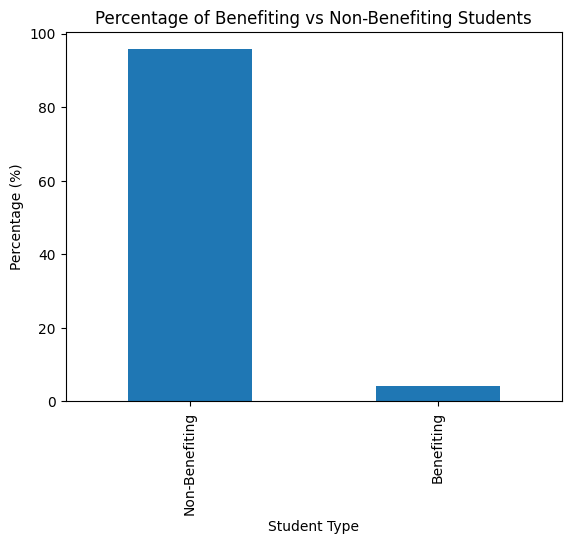

In [594]:
benefit_counts = df['Student_Type'].value_counts()

benefit_percentage = (benefit_counts / len(df)) * 100

print(benefit_percentage)
import matplotlib.pyplot as plt

benefit_percentage.plot(kind='bar')

plt.title("Percentage of Benefiting vs Non-Benefiting Students")
plt.xlabel("Student Type")
plt.ylabel("Percentage (%)")
plt.savefig("chart17.png", dpi=300, bbox_inches='tight')
plt.show()

AI_Ethics_Concern       High        Low     Medium
Usage_Level                                       
High Usage         35.883171  33.796940  30.319889
Low Usage          30.473752  35.851472  33.674776


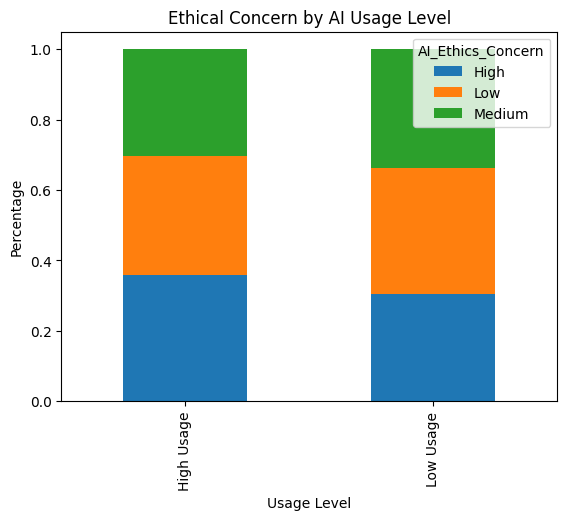

In [595]:
df['Usage_Level'] = df['Task_Frequency_Daily'].apply(
    lambda x: 'High Usage' if x > df['Task_Frequency_Daily'].median() else 'Low Usage'
)
import pandas as pd

result = pd.crosstab(
    df['Usage_Level'],
    df['AI_Ethics_Concern'],
    normalize='index'
) * 100

print(result)
import matplotlib.pyplot as plt

pd.crosstab(
    df['Usage_Level'],
    df['AI_Ethics_Concern'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.title("Ethical Concern by AI Usage Level")
plt.xlabel("Usage Level")
plt.ylabel("Percentage")
plt.savefig("ethics.png", dpi=300, bbox_inches='tight')
plt.show()

In [596]:
print(pd.crosstab(df['Usage_Level'], df['AI_Ethics_Concern']))

AI_Ethics_Concern  High  Low  Medium
Usage_Level                         
High Usage          258  243     218
Low Usage           238  280     263


In [597]:
 !ls *.png


chart10.png  chart14.png  chart2.png  chart6.png  ethics.png
chart11.png  chart16.png  chart3.png  chart7.png  major.png
chart12.png  chart17.png  chart4.png  chart8.png  tool.png
chart13.png  chart1.png   chart5.png  chart9.png


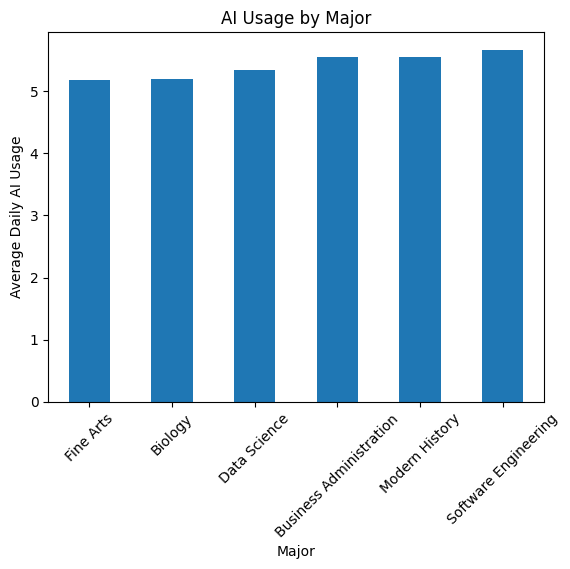

In [598]:
import matplotlib.pyplot as plt

usage_by_major = df.groupby('Major')['Task_Frequency_Daily'].mean().sort_values()

plt.figure()
usage_by_major.plot(kind='bar')

plt.title("AI Usage by Major")
plt.xlabel("Major")
plt.ylabel("Average Daily AI Usage")
plt.xticks(rotation=45)
plt.savefig("major.png", dpi=300, bbox_inches='tight')
plt.show()

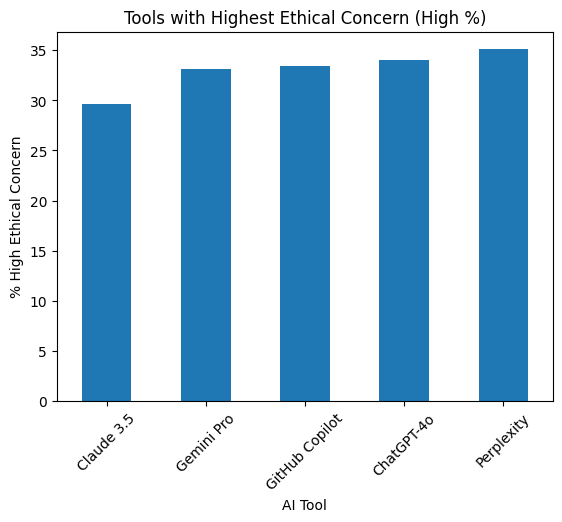

In [599]:
import matplotlib.pyplot as plt

tool_ethics = pd.crosstab(
    df['Primary_AI_Tool'],
    df['AI_Ethics_Concern'],
    normalize='index'
) * 100

plt.figure()
tool_ethics['High'].sort_values().plot(kind='bar')

plt.title("Tools with Highest Ethical Concern (High %)")
plt.xlabel("AI Tool")
plt.ylabel("% High Ethical Concern")
plt.xticks(rotation=45)
plt.savefig("tool.png", dpi=300, bbox_inches='tight')
plt.show()

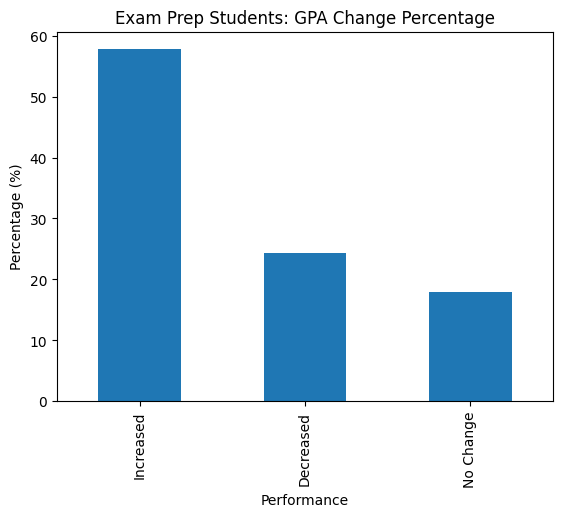

In [600]:
df['Main_Usage_Case'].value_counts()
exam_df = df[df['Main_Usage_Case'].str.contains("exam", case=False, na=False)]
exam_df = exam_df.copy()

exam_df['GPA_Change'] = exam_df['GPA_Post_AI'] - exam_df['GPA_Baseline']

exam_df['Performance'] = exam_df['GPA_Change'].apply(
    lambda x: 'Increased' if x > 0 else ('Decreased' if x < 0 else 'No Change')
)
import matplotlib.pyplot as plt

percent = exam_df['Performance'].value_counts(normalize=True) * 100

percent.plot(kind='bar')

plt.title("Exam Prep Students: GPA Change Percentage")
plt.xlabel("Performance")
plt.ylabel("Percentage (%)")
plt.show()

In [601]:
df['Main_Usage_Case'].value_counts()

,count
Main_Usage_Case,
Exam Prep,341
Literature Review,308
Essay Drafting,301
Brainstorming,286
Code Debugging,264


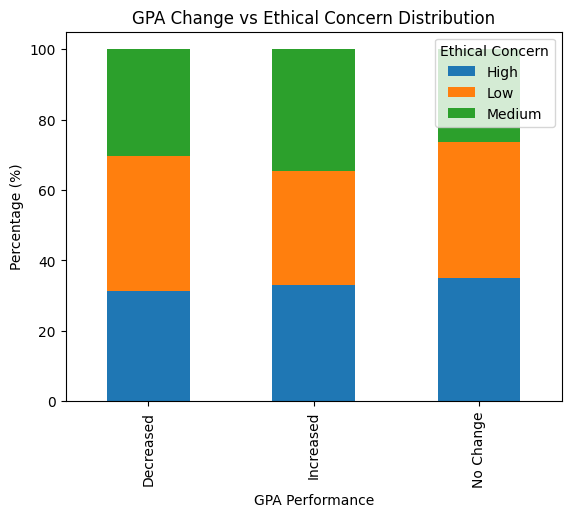

In [602]:
df['GPA_Change'] = df['GPA_Post_AI'] - df['GPA_Baseline']
df['Performance'] = df['GPA_Change'].apply(
    lambda x: 'Increased' if x > 0 else ('Decreased' if x < 0 else 'No Change')
)
import matplotlib.pyplot as plt
import pandas as pd

cross = pd.crosstab(df['Performance'], df['AI_Ethics_Concern'], normalize='index') * 100

cross.plot(kind='bar', stacked=True)

plt.title("GPA Change vs Ethical Concern Distribution")
plt.xlabel("GPA Performance")
plt.ylabel("Percentage (%)")
plt.legend(title="Ethical Concern")
plt.show()